In [2]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

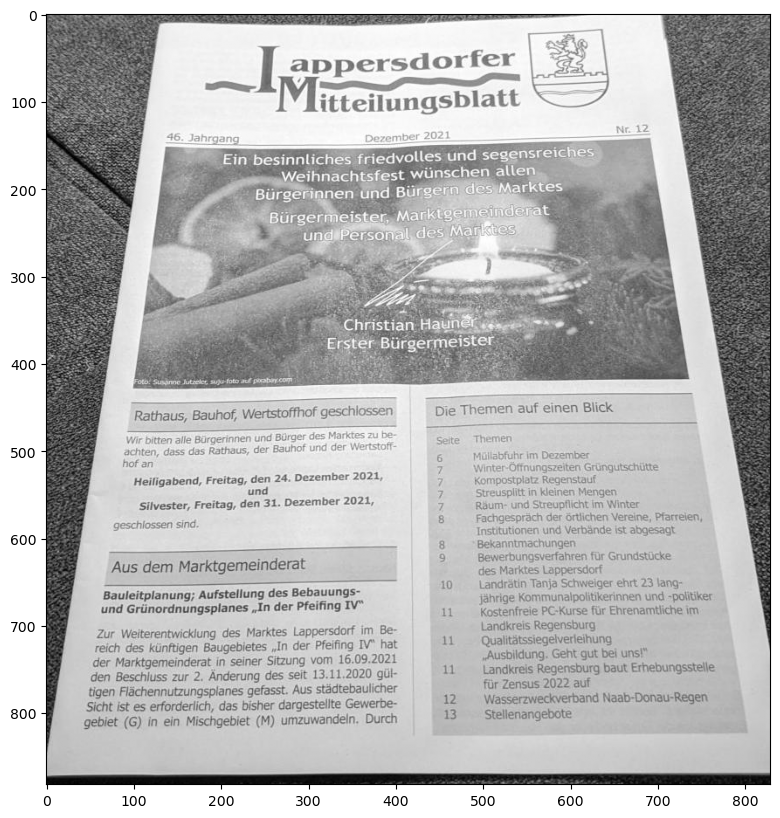

In [3]:
img = cv2.imread('document.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap='gray')


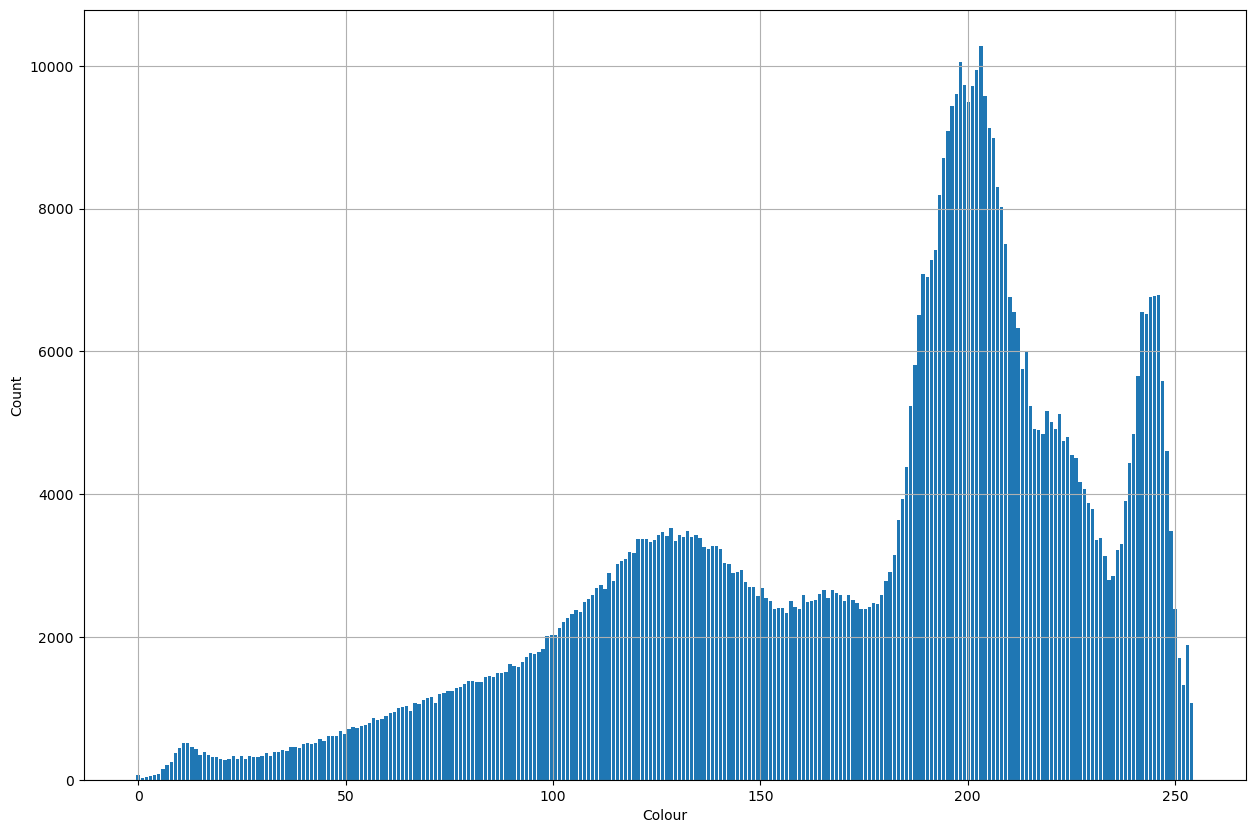

In [4]:
h = np.histogram(img, 256)
plt.bar(h[1][0:-1], h[0])
plt.xlabel('Colour'), plt.ylabel('Count')
plt.grid(True)

In [12]:

# Get image dimensions
rows, cols = img.shape
# Compute the total amount of image pixels
num_pixels = rows * cols

# Initializations
best_wcv = 1e6  # Best within-class variance (wcv)
opt_th = None   # Threshold corresponding to the best wcv

# Brute force search using all possible thresholds (levels of gray)
for th in range(0, 256):
    # Extract the image pixels corresponding to the foreground
    foreground = img[img > th]
    # Extract the image pixels corresponding to the background
    background = img[img <= th]
    
    # If foreground or background are empty, continue
    if len(foreground) == 0 or len(background) == 0:
        continue
    
    # Compute class-weights (omega parameters) for foreground and background
    omega_f = len(foreground)/num_pixels
    omega_b = len(background)/num_pixels
    
    # Compute pixel variance for foreground and background
    # Hint: Check out the var function from numpy ;-)
    # https://numpy.org/doc/stable/reference/generated/numpy.var.html
    sigma2_f = np.var(foreground)
    sigma2_b = np.var(background)
    
    # Compute the within-class variance
    wcv = omega_f * sigma2_f + omega_b * sigma2_b
    
    # Perform the optimization
    if wcv < best_wcv:
        best_wcv = wcv
        opt_th = th
        
# Print out the optimal threshold found by Otsu algorithm
print('Optimal threshold', opt_th)

# Compare with OpenCV’s built-in Otsu
otsu_th, otsu_cv = cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)
print("OpenCV Otsu threshold:", otsu_th)

Optimal threshold 159
OpenCV Otsu threshold: 159.0


(<Axes: >, <matplotlib.image.AxesImage at 0x10bf98b90>)

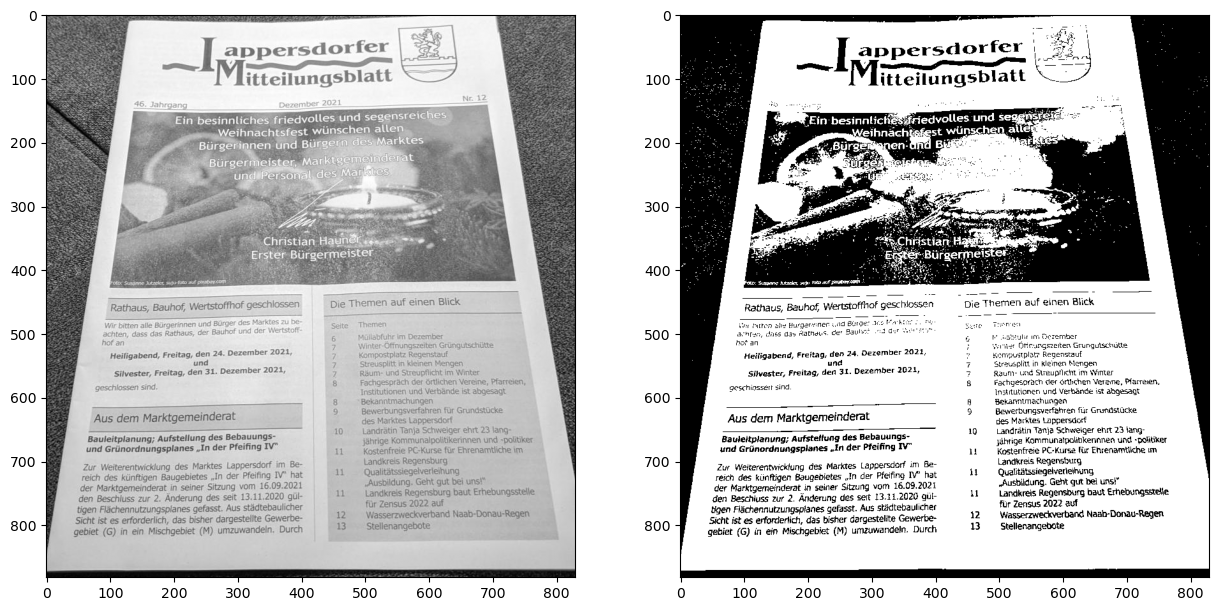

In [15]:
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.subplot(122), plt.imshow(img > opt_th, cmap='gray')

# Looking at the computed histogram, could it be considered bimodal?
#    - Histogram has 2 peaks for colors 200 and 240 but I still would not consider as bimodal because there a lot to of pixels in othe range
# Looking at the computed histogram, what binarization threshold would you chose? Why?
#    - based on histogram I would chose something between 165<>180
# Looking at the resulting (thresholded) image, is the text binarization (detection) good? 
#    - No. We got bad result for text on gray screen. Also the same for white text on picture with noise